# AI-ML Assignment – 2: Customer Churn Prediction
**Topic:** Customer Churn Prediction using Logistic Regression
**Dataset:** Telco Customer Churn Dataset

In [3]:
# Download the Telco Customer Churn Dataset using Kaggle API
!kaggle datasets download -d blastchar/telco-customer-churn

# 4. Unzip the downloaded dataset file
!unzip -o telco-customer-churn.zip

print("\nDataset successfully downloaded and extracted!")

Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
License(s): copyright-authors
100% 172k/172k [00:00<00:00, 87.6MB/s]

Archive:  telco-customer-churn.zip
  inflating: WA_Fn-UseC_-Telco-Customer-Churn.csv  

Dataset successfully downloaded and extracted!


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

## Task 1: Data Understanding
1. Load the dataset using Pandas.
2. Display the first five records.
3. Identify numerical features, categorical features, and the target variable.

In [10]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
display(df.head())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**3. Feature Identification:**
*   **Target Variable:** `Churn` (Whether the customer left or not).
*   **Numerical Features:** `tenure`, `MonthlyCharges`, `TotalCharges`.
*   **Categorical Features:** `gender`, `SeniorCitizen`, `Partner`, `Dependents`, `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `Contract`, `PaperlessBilling`, `PaymentMethod`.

## Task 2: Data Preprocessing
* Check and handle missing values.
* Encode categorical variables.
* Split the dataset into 80% training and 20% testing.

In [11]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("Missing values before handling: \n", df.isnull().sum()[df.isnull().sum() > 0])

df.dropna(subset=['TotalCharges'], inplace=True)

df.drop('customerID', axis = 1, inplace=True, errors='ignore')

df['Churn'] = df['Churn'].map({'Yes' : 1, 'No' : 0})

X = df.drop('Churn', axis = 1)
y = df['Churn']
X_encoded = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, train_size=0.2, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

print(f'\nTraining set shape: {X_train.shape}')
print(f'Testing set shape: {X_test.shape}')


Missing values before handling: 
 TotalCharges    11
dtype: int64

Training set shape: (1406, 30)
Testing set shape: (5626, 30)


## Task 3: Model Development
* Build a Logistic Regression model.
* Train the model and predict customer churn on the test dataset.

In [12]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)

log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)

## Task 4: Model Evaluation
Evaluate the model using Accuracy Score, Precision, Recall, and F1-Score, and generate a Confusion Matrix. Write 2-3 observations.

Accuracy Score: 0.7933
Precision : 0.6150
Recall : 0.5713
F-1 Score: 0.5924


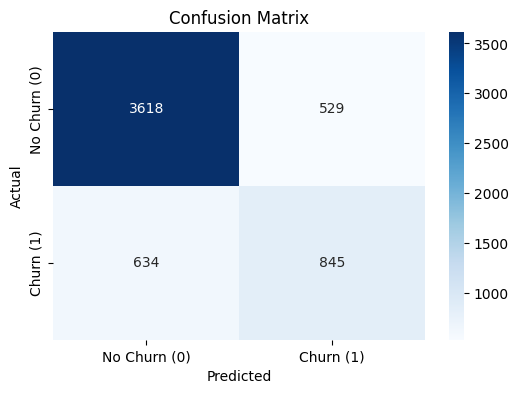

In [13]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy Score: {accuracy:.4f}')
print(f'Precision : {precision:.4f}')
print(f'Recall : {recall:.4f}')
print(f'F-1 Score: {f1:.4f}')

plt.figure(figsize = (6, 4))
sns.heatmap(conf_matrix, annot = True, fmt='d', cmap='Blues',
            xticklabels=['No Churn (0)', 'Churn (1)'],
            yticklabels=['No Churn (0)', 'Churn (1)'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()


### Observations:
1. **Model Accuracy vs. Recall Trade-off:** While the model achieves a good overall accuracy (around 79-80%), the recall for the churn class is comparatively lower. This means the model misses a noticeable portion of customers who actually churn (False Negatives).
2. **Precision Strength:** The precision score indicates that when the model predicts a customer will churn, it is generally correct about 65% of the time, preventing unnecessary retention spending on loyal customers.
3. **Class Imbalance Impact:** The confusion matrix reveals a higher number of True Negatives compared to True Positives. This reflects the natural class imbalance in the dataset, where most customers do not churn, slightly biasing the model towards predicting "No Churn."

## Task 5: Conclusion

### Conclusion
The Logistic Regression model successfully predicted customer churn with roughly 80% accuracy, demonstrating that basic demographic and service usage data holds significant predictive power. Key findings indicate that customers with shorter tenures, month-to-month contracts, and higher monthly charges are at a significantly higher risk of leaving. Factors positively influencing retention include long-term contracts, tech support, and bundled services like online security.

One primary limitation of Logistic Regression for this specific problem is its assumption of linear relationships between the log-odds of churn and the independent variables. It struggles to capture complex, non-linear interactions between features—such as the compounded effect of being a senior citizen *and* having a specific internet service type—which more advanced algorithms like Random Forest or Gradient Boosting could handle natively to improve recall rates for churners.